In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('final_input.csv')
df.drop('sample-name', axis=1, inplace=True)

In [3]:
def shannon_diversity(index, base=np.e):
    proportions = index / index.sum()
    proportions = proportions[proportions > 0]  # filter out zero values to avoid math errors
    return -np.sum(proportions * np.log(proportions) / np.log(base))


df['alpha_diversity'] = df.apply(shannon_diversity, axis=1)


In [4]:
from scipy.stats import mannwhitneyu

group_control = df[df['AB_used'] == 0]['alpha_diversity']
group_patient = df[df['AB_used'] == 1]['alpha_diversity']

stat, p_value = mannwhitneyu(group_control, group_patient, alternative='two-sided')

print(f"Wilcoxon rank-sum statistic: {stat}")
print(f"P-value: {p_value}")


Wilcoxon rank-sum statistic: 291203.5
P-value: 8.955617992402348e-43


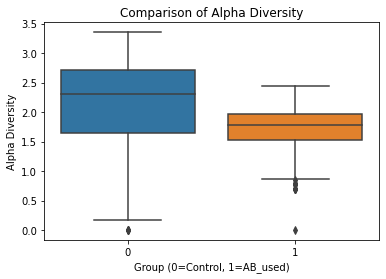

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='AB_used', y='alpha_diversity', data=df)
plt.title('Comparison of Alpha Diversity')
plt.xlabel('Group (0=Control, 1=AB_used)')
plt.ylabel('Alpha Diversity')
plt.show()
